# Naive Bayes Text Classification (Reviews)

Step-by-step workflow using a CSV dataset.

## Step 1: Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Load Dataset

In [2]:
df = pd.read_csv("dataset/sentiment.xls")

print("First 5 rows:")
print(df.head())

df = df.iloc[:, 1:]

print("\nColumn names:")
print(df.columns)

First 5 rows:
   Unnamed: 0                                               text  sentiment
0           0  So there is no way for me to plug it in here i...          0
1           1                         Good case Excellent value.          1
2           2                             Great for the jawbone.          1
3           3  Tied to charger for conversations lasting more...          0
4           4                                  The mic is great.          1

Column names:
Index(['text', 'sentiment'], dtype='str')


## Step 3: Shuffle Dataframe

In [3]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataframe shuffled!")

Dataframe shuffled!


## Step 4: Prepare Features and Labels

In [4]:
X = df["text"]
y = df["sentiment"]

print("Sample review:")
print(X.iloc[0])
print("Label:", y.iloc[0])

Sample review:
Best headset ever!!!.
Label: 1


## Step 5: Train-Test Split

Training size: 1593
Testing size: 399


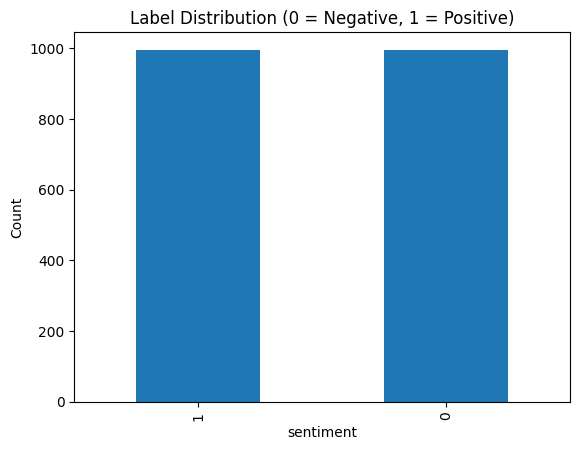

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Label Distribution (0 = Negative, 1 = Positive)")
plt.xlabel("sentiment")
plt.ylabel("Count")
plt.show()

## Step 6: Convert Text to TF-IDF Features

In [6]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Feature matrix shape:", X_train_vec.shape)

Feature matrix shape: (1593, 2607)


## Step 7: Train Naive Bayes Model

In [7]:
model = MultinomialNB()
model.fit(X_train_vec, y_train)

print("Model trained!")

Model trained!


## Step 8: Make Predictions

In [8]:
y_pred = model.predict(X_test_vec)

print("Sample predictions:", y_pred[:10])

Sample predictions: [1 0 0 1 1 1 1 0 1 0]


## Step 9: Evaluate Model

Accuracy: 0.8120300751879699

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.73      0.80       200
           1       0.77      0.89      0.83       199

    accuracy                           0.81       399
   macro avg       0.82      0.81      0.81       399
weighted avg       0.82      0.81      0.81       399


Confusion Matrix:


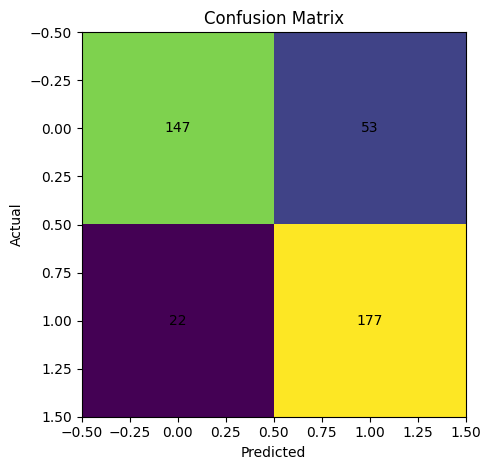

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside the heatmap
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [10]:
feature_names = np.array(vectorizer.get_feature_names_out())

# Get log probabilities
log_probs = model.feature_log_prob_

# Top words for class 1 (positive)
top_pos = feature_names[np.argsort(log_probs[1])[-15:]]

# Top words for class 0 (negative)
top_neg = feature_names[np.argsort(log_probs[0])[-15:]]

print("Top Positive Words:")
print(top_pos)

print("\nTop Negative Words:")
print(top_neg)

Top Positive Words:
['recommend' 'product' 'really' 'best' 'price' 'love' 'nice' 'excellent'
 'works' 'food' 'place' 'service' 'phone' 'good' 'great']

Top Negative Words:
['terrible' 'time' 'disappointed' 'worst' 'work' 'like' 'money' 'poor'
 'waste' 'bad' 'place' 'don' 'food' 'phone' 'service']


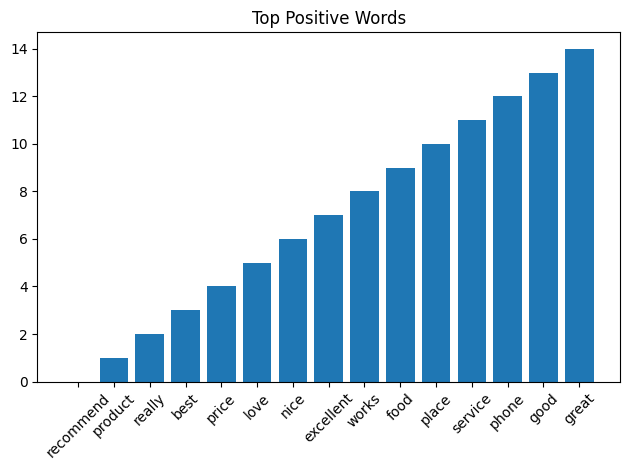

In [11]:
plt.figure()
plt.bar(range(len(top_pos)), range(len(top_pos)))
plt.xticks(range(len(top_pos)), top_pos, rotation=45)
plt.title("Top Positive Words")
plt.tight_layout()
plt.show()

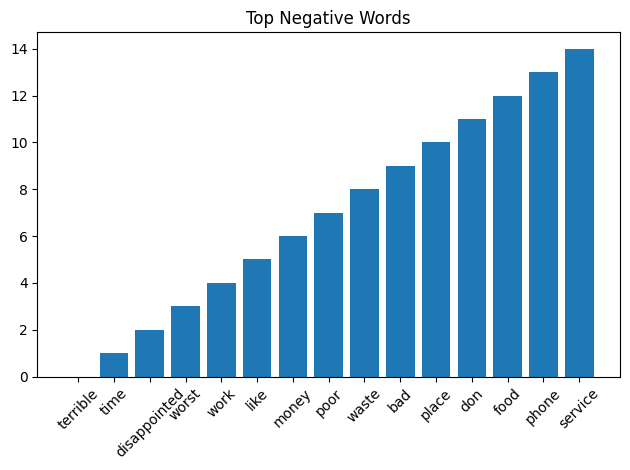

In [12]:
plt.figure()
plt.bar(range(len(top_neg)), range(len(top_neg)))
plt.xticks(range(len(top_neg)), top_neg, rotation=45)
plt.title("Top Negative Words")
plt.tight_layout()
plt.show()